# CPCV Strategy Comparison via MLflow

Reads the parent-run metrics from each CPCV experiment and plots bar charts for:
- Mean Sharpe Ratio across CPCV paths
- Sharpe Ratio Variance across CPCV paths
- Mean Probabilistic Sharpe Ratio (PSR) across CPCV paths

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import matplotlib.pyplot as plt
import mlflow
import pandas as pd

TRACKING_URI = f"sqlite:///{project_root}/mlflow.db"
mlflow.set_tracking_uri(TRACKING_URI)

EXPERIMENT_NAMES = [
    "CPCV_SmaCross",
    "CPCV_MaCrossover",
    "CPCV_BollingerBands",
    "CPCV_MACD",
    "CPCV_RSIDivergence",
    "CPCV_MultiIndicator",
]

## Load parent-run metrics from MLflow

In [3]:
client = mlflow.tracking.MlflowClient()

records = []
for exp_name in EXPERIMENT_NAMES:
    experiment = client.get_experiment_by_name(exp_name)
    if experiment is None:
        print(f"[WARN] Experiment not found: {exp_name}")
        continue

    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="tags.mlflow.parentRunId = ''",  # parent runs only
        order_by=["start_time DESC"],
    )
    # Fall back to all top-level runs if tag filter returns nothing
    if not runs:
        runs = client.search_runs(
            experiment_ids=[experiment.experiment_id],
            order_by=["start_time DESC"],
        )
        runs = [r for r in runs if not r.data.tags.get("mlflow.parentRunId")]

    if not runs:
        print(f"[WARN] No parent runs found for: {exp_name}")
        continue

    # Use the most recent parent run
    run = runs[0]
    metrics = run.data.metrics
    records.append(
        {
            "strategy": exp_name.replace("CPCV_", ""),
            "sharpe_mean": metrics.get("sharpe_mean", float("nan")),
            "sharpe_variance": metrics.get("sharpe_std", float("nan")) ** 2,
            "psr_mean": metrics.get("psr_mean", float("nan")),
        }
    )

df = pd.DataFrame(records).set_index("strategy")
print(df.to_string())

2026/05/02 12:19:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/02 12:19:37 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


                sharpe_mean  sharpe_variance  psr_mean
strategy                                              
SmaCross           0.287771         0.014058  0.794812
MaCrossover       -0.474492         0.097094  0.205781
BollingerBands     0.052558         0.023766  0.553463
MACD               0.161876         0.024175  0.676429
RSIDivergence      0.539948         0.009064  0.963921
MultiIndicator     0.701651         0.033860  0.987230


## Bar Charts

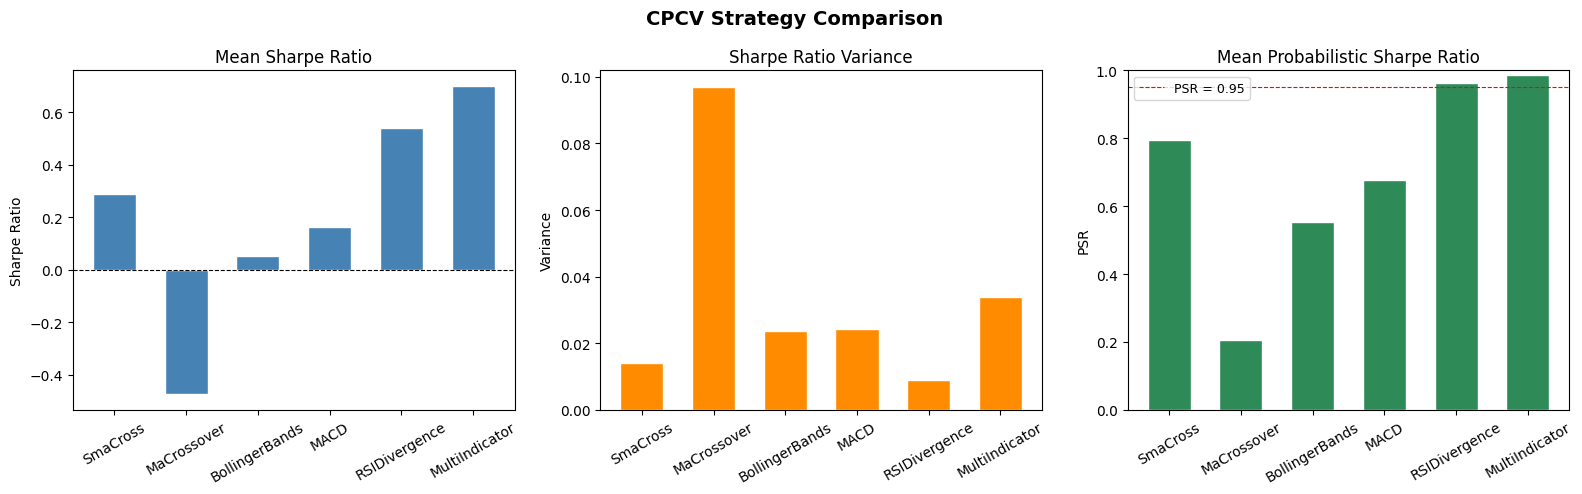

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("CPCV Strategy Comparison", fontsize=14, fontweight="bold")

bar_kwargs = dict(color="steelblue", edgecolor="white", width=0.6)

axes[0].bar(df.index, df["sharpe_mean"], **bar_kwargs)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Mean Sharpe Ratio")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(df.index, df["sharpe_variance"], color="darkorange", edgecolor="white", width=0.6)
axes[1].set_title("Sharpe Ratio Variance")
axes[1].set_ylabel("Variance")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(df.index, df["psr_mean"], color="seagreen", edgecolor="white", width=0.6)
axes[2].axhline(0.95, color="red", linewidth=0.8, linestyle="--", label="PSR = 0.95")
axes[2].set_ylim(0, 1)
axes[2].set_title("Mean Probabilistic Sharpe Ratio")
axes[2].set_ylabel("PSR")
axes[2].legend(fontsize=9)
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()